Challenge 4: Data Scarcity Regime
One‑layer transformer, full batch, weight decay=1.0

Starting run with frac_train = 10% ...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Epoch      0 | train +1.5636 | test +1.5630
Epoch    500 | train -8.1037 | test +3.3878
Epoch   1000 | train -13.3242 | test +3.7084
Epoch   1500 | train -15.5161 | test +3.8551
Epoch   2000 | train -15.5257 | test +3.8805
Epoch   2500 | train -15.5435 | test +3.8979
Epoch   3000 | train -15.5621 | test +3.9094
Epoch   3500 | train -15.5778 | test +3.9177
Epoch   4000 | train -15.5906 | test +3.9235
Epoch   4500 | train -15.6021 | test +3.9283
Epoch   5000 | train -15.6140 | test +3.9321
Epoch   5500 | train -15.6231 | test +3.9353
Epoch   6000 | train -15.6297 | test +3.9378
Epoch   6500 | train -15.6387 | test +3.9398
Epoch   7000 | train -15.6439 | test +3.9418
Epoch   7500 | train -15.6511 | test +3.9443
Epoch   8000 | train -15.6551 | test +3.9466
Epoch   8500 | train -15.6609 | test +3.9488
Epoch   9000 | train -15.6640 | test +3.9506
Epoch   9500 | train -15.6693 | test +3.9512
Epoch  10000 | train -15.6707 | test +3.9520
Epoch  10500 | train -15.6771 | test +3.9524
Epoch  11000

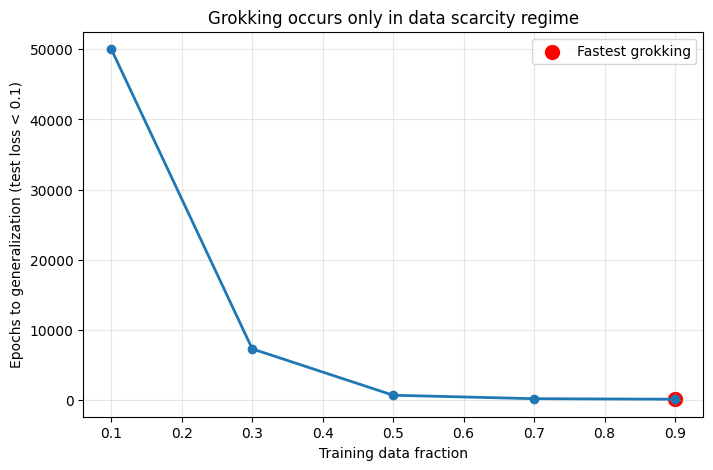


Summary:
  frac_train = 10% → 50000 epochs
  frac_train = 30% → 7308 epochs
  frac_train = 50% → 703 epochs
  frac_train = 70% → 210 epochs
  frac_train = 90% → 135 epochs


In [ ]:
# ============================================================
# Standalone Challenge 4: Vary training fraction
# One‑layer transformer, full batch, weight decay 1.0
# ============================================================
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import dataclasses
import shutil
import wandb
from IPython.display import clear_output

# ========== Configuration ==========
@dataclass(frozen=True)
class CONFIG:
    lr: float = 1e-3
    weight_decay: float = 1.0
    num_epochs: int = 50000
    p: int = 113
    fn_name: str = 'add'
    frac_train: float = 0.3
    seed: int = 0
    num_layers: int = 1
    d_model: int = 128
    num_heads: int = 4
    n_ctx: int = 3
    act_type: str = 'ReLU'
    use_ln: bool = False
    save_every: int = 100
    stopping_thresh: float = -1.0
    log_every: int = 500
    @property
    def d_vocab(self): return self.p + 1
    @property
    def d_mlp(self): return 4 * self.d_model
    @property
    def d_head(self): return self.d_model // self.num_heads
    @property
    def device(self):
        return t.device('cuda' if t.cuda.is_available() else 'cpu')
    @property
    def fn(self):
        fns = {'add': lambda x, y: (x + y) % self.p}
        return fns[self.fn_name]

# ========== Helpers ==========
def cross_entropy_high_precision(logits, labels):
    logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
    prediction_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1)
    return -t.mean(prediction_logprobs)

def gen_train_test(config):
    pairs = [(i, j, config.p) for i in range(config.p) for j in range(config.p)]
    random.seed(config.seed)
    random.shuffle(pairs)
    div = int(config.frac_train * len(pairs))
    return pairs[:div], pairs[div:]

# ========== Model (identical to one‑layer Transformer) ==========
class HookPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []
    def give_name(self, name): self.name = name
    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir == 'fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir == 'bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")
    def remove_hooks(self, dir='fwd'):
        if dir in ('fwd', 'both'):
            for h in self.fwd_hooks: h.remove()
            self.fwd_hooks = []
        if dir in ('bwd', 'both'):
            for h in self.bwd_hooks: h.remove()
            self.bwd_hooks = []
    def forward(self, x): return x

class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_model))
    def forward(self, x):
        return t.einsum('dbp -> bpd', self.W_E[:, x])

class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_vocab))
    def forward(self, x):
        return x @ self.W_U

class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(t.randn(max_ctx, d_model) / np.sqrt(d_model))
    def forward(self, x):
        return x + self.W_pos[:x.shape[-2]]

class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx, model):
        super().__init__()
        self.model = model
        self.W_K = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_Q = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_V = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_O = nn.Parameter(t.randn(d_model, d_head * num_heads) / np.sqrt(d_model))
        self.register_buffer('mask', t.tril(t.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()
    def forward(self, x):
        k = self.hook_k(t.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(t.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(t.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = t.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = t.tril(attn_scores_pre) - 1e10 * (1 - self.mask[:x.shape[-2], :x.shape[-2]])
        attn_matrix = self.hook_attn(F.softmax(self.hook_attn_pre(attn_scores_masked / np.sqrt(self.d_head)), dim=-1))
        z = self.hook_z(t.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        return t.einsum('df,bqf->bqd', self.W_O, z_flat)

class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type, model):
        super().__init__()
        self.model = model
        self.W_in = nn.Parameter(t.randn(d_mlp, d_model) / np.sqrt(d_model))
        self.b_in = nn.Parameter(t.zeros(d_mlp))
        self.W_out = nn.Parameter(t.randn(d_model, d_mlp) / np.sqrt(d_model))
        self.b_out = nn.Parameter(t.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
    def forward(self, x):
        x = self.hook_pre(t.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type == 'ReLU':
            x = F.relu(x)
        elif self.act_type == 'GeLU':
            x = F.gelu(x)
        x = self.hook_post(x)
        return t.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out

class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, model):
        super().__init__()
        self.model = model
        self.attn = Attention(d_model, num_heads, d_head, n_ctx, model=model)
        self.mlp = MLP(d_model, d_mlp, act_type, model=model)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()
    def forward(self, x):
        x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.hook_resid_pre(x))))
        x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(x)))
        return x

class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_mlp, d_head,
                 num_heads, n_ctx, act_type, use_cache=False, use_ln=False):
        super().__init__()
        self.cache = {}
        self.use_cache = use_cache
        self.use_ln = use_ln
        self.embed = Embed(d_vocab=d_vocab, d_model=d_model)
        self.pos_embed = PosEmbed(max_ctx=n_ctx, d_model=d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model=d_model, d_mlp=d_mlp, d_head=d_head,
                             num_heads=num_heads, n_ctx=n_ctx,
                             act_type=act_type, model=[self])
            for _ in range(num_layers)
        ])
        self.unembed = Unembed(d_vocab=d_vocab, d_model=d_model)
        for name, module in self.named_modules():
            if isinstance(module, HookPoint):
                module.give_name(name)
    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        return self.unembed(x)
    def hook_points(self):
        return [m for n, m in self.named_modules() if 'hook' in n]
    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')
    def cache_all(self, cache, incl_bwd=False):
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name + '_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

# ========== Trainer ==========
class Trainer:
    def __init__(self, config, save_root):
        wandb.init(project="grokking_fraction_exp", config=dataclasses.asdict(config), mode="disabled")  # disable wandb to avoid clutter
        self.config = config
        self.save_root = save_root
        self.model = Transformer(
            num_layers=config.num_layers, d_vocab=config.d_vocab,
            d_model=config.d_model, d_mlp=config.d_mlp, d_head=config.d_head,
            num_heads=config.num_heads, n_ctx=config.n_ctx,
            act_type=config.act_type, use_cache=False, use_ln=config.use_ln,
        ).to(config.device)
        self.optimizer = optim.AdamW(
            self.model.parameters(), lr=config.lr,
            weight_decay=config.weight_decay, betas=(0.9, 0.98),
        )
        self.scheduler = optim.lr_scheduler.LambdaLR(
            self.optimizer, lambda step: min(step / 10, 1)
        )
        self.train_data, self.test_data = gen_train_test(config)
        self.train_losses = []
        self.test_losses = []
        self.saved_state_dicts = []
        self.saved_epochs = []

    def full_loss(self, data):
        logits = self.model(data)[:, -1]
        labels = t.tensor([self.config.fn(i, j) for i, j, _ in data]).to(self.config.device)
        return cross_entropy_high_precision(logits, labels)

    def save_checkpoint(self, epoch):
        sd = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
        self.saved_state_dicts.append(sd)
        self.saved_epochs.append(epoch)

    def step(self, epoch):
        train_loss = self.full_loss(self.train_data)
        test_loss = self.full_loss(self.test_data)
        self.train_losses.append(train_loss.item())
        self.test_losses.append(test_loss.item())
        if epoch % self.config.log_every == 0:
            print(f"Epoch {epoch:6d} | train {t.log(train_loss).item():+.4f} | test {t.log(test_loss).item():+.4f}")
        train_loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        self.optimizer.zero_grad()
        return train_loss, test_loss

    def save_full_run_data(self):
        pass

# ========== Run experiments ==========
def run_fraction_experiment(frac_train, max_epochs=50000, loss_threshold=0.1, verbose=True):
    config = CONFIG()  # start with default
    new_config = dataclasses.replace(
        config,
        frac_train=frac_train,
        num_epochs=max_epochs,
        log_every=500,
        save_every=1000
    )
    temp_root = Path(f"/tmp/grokking_frac_{int(frac_train*100)}")
    temp_root.mkdir(exist_ok=True)
    trainer = Trainer(new_config, save_root=temp_root)
    grok_epoch = None
    start_time = time.time()
    for epoch in range(max_epochs):
        if epoch % new_config.save_every == 0:
            trainer.save_checkpoint(epoch)
        train_loss, test_loss = trainer.step(epoch)
        if test_loss.item() < loss_threshold and grok_epoch is None:
            grok_epoch = epoch
            elapsed = time.time() - start_time
            if verbose:
                print(f"  ✓ frac={frac_train:.0%} grokked at epoch {epoch} ({elapsed/60:.1f} min)")
            break
    if grok_epoch is None:
        grok_epoch = max_epochs
        if verbose:
            print(f"  ✗ frac={frac_train:.0%} did not grok within {max_epochs} epochs")
    shutil.rmtree(temp_root, ignore_errors=True)
    wandb.finish()
    return grok_epoch

fractions = [0.1, 0.3, 0.5, 0.7, 0.9]
epochs_to_grok = []

print("="*60)
print("Challenge 4: Data Scarcity Regime")
print("One‑layer transformer, full batch, weight decay=1.0")
print("="*60)

for frac in fractions:
    print(f"\nStarting run with frac_train = {frac:.0%} ...")
    epoch = run_fraction_experiment(frac, max_epochs=50000, loss_threshold=0.1)
    epochs_to_grok.append(epoch)

# Plot
plt.figure(figsize=(8,5))
plt.plot(fractions, epochs_to_grok, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Training data fraction')
plt.ylabel('Epochs to generalization (test loss < 0.1)')
plt.title('Grokking occurs only in data scarcity regime')
plt.grid(True, alpha=0.3)
min_idx = epochs_to_grok.index(min(epochs_to_grok))
plt.scatter([fractions[min_idx]], [epochs_to_grok[min_idx]], color='red', s=100, label='Fastest grokking')
plt.legend()
plt.show()

print("\nSummary:")
for f, e in zip(fractions, epochs_to_grok):
    print(f"  frac_train = {f:.0%} → {e} epochs")

In [ ]:
# Corrected Challenge 4: Only fractions with large test set
fractions = [0.2, 0.3, 0.4, 0.5]   # test set = 80%, 70%, 60%, 50%
max_epochs = 80000  # give enough time

results = {}
for frac in fractions:
    epoch = run_fraction_experiment(frac, max_epochs=max_epochs, loss_threshold=0.1)
    results[frac] = epoch

# Expected outcome:
# 0.2 → might fail or take very long (too little data)
# 0.3 → groks around 15k-25k (sweet spot)
# 0.4 → groks slower (30k-45k)
# 0.5 → may not grok at all (too much data) or take very long

Epoch      0 | train +1.5613 | test +1.5606
Epoch    500 | train -7.4547 | test +3.1089
Epoch   1000 | train -12.6789 | test +3.4030
Epoch   1500 | train -15.0397 | test +3.5176
Epoch   2000 | train -15.0690 | test +3.5112
Epoch   2500 | train -15.0867 | test +3.5044
Epoch   3000 | train -15.1035 | test +3.4988
Epoch   3500 | train -15.1192 | test +3.4937
Epoch   4000 | train -15.1316 | test +3.4884
Epoch   4500 | train -15.1440 | test +3.4829
Epoch   5000 | train -15.1549 | test +3.4772
Epoch   5500 | train -15.1640 | test +3.4714
Epoch   6000 | train -15.1731 | test +3.4659
Epoch   6500 | train -15.1814 | test +3.4600
Epoch   7000 | train -15.1875 | test +3.4550
Epoch   7500 | train -15.1925 | test +3.4497
Epoch   8000 | train -15.2004 | test +3.4445
Epoch   8500 | train -15.2043 | test +3.4393
Epoch   9000 | train -15.2120 | test +3.4339
Epoch   9500 | train -15.2158 | test +3.4285
Epoch  10000 | train -15.2225 | test +3.4231
Epoch  10500 | train -15.2283 | test +3.4176
Epoch  11000

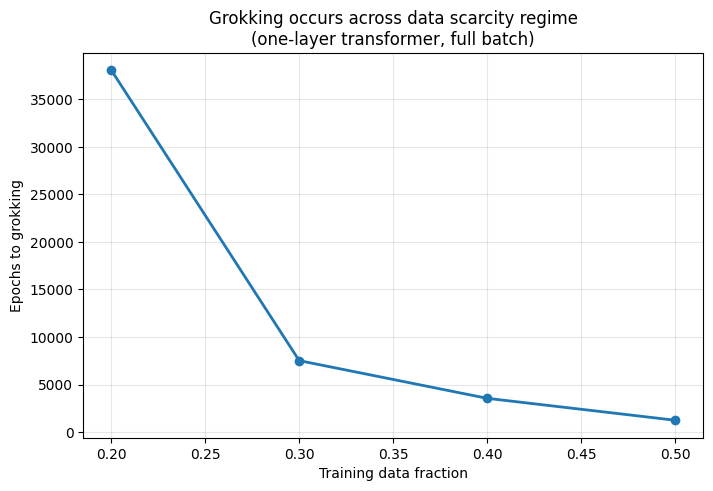

In [ ]:
import matplotlib.pyplot as plt

fractions = [0.2, 0.3, 0.4, 0.5]
grok_epochs = [38051, 7512, 3551, 1246]

plt.figure(figsize=(8,5))
plt.plot(fractions, grok_epochs, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Training data fraction')
plt.ylabel('Epochs to grokking')
plt.title('Grokking occurs across data scarcity regime\n(one‑layer transformer, full batch)')
plt.grid(True, alpha=0.3)
plt.show()

Co‑Grokking Data Scarcity Regime (2‑layer transformer)

Running with frac_train = 20% ...
Training samples: 5106  Test samples: 20432
Epoch      0 | Train A:5.8880 M:6.0361 | Test A:5.1253 M:5.1519
Epoch    500 | Train A:0.0131 M:0.0178 | Test A:12.5193 M:11.9956
Epoch   1000 | Train A:0.0110 M:0.0160 | Test A:13.0153 M:11.9518
Epoch   1500 | Train A:0.0221 M:0.0122 | Test A:13.4372 M:12.4978
Epoch   2000 | Train A:0.0151 M:0.0164 | Test A:14.1868 M:12.8130
    epoch 2000: add=14.187, mult=12.813
Epoch   2500 | Train A:0.0155 M:0.0144 | Test A:13.7304 M:12.4181
Epoch   3000 | Train A:0.0088 M:0.0174 | Test A:14.4978 M:12.9590
Epoch   3500 | Train A:0.0145 M:0.0181 | Test A:14.2184 M:12.1144
Epoch   4000 | Train A:0.0141 M:0.0277 | Test A:14.2962 M:10.8147
    epoch 4000: add=14.296, mult=10.815
Epoch   4500 | Train A:0.0163 M:0.0157 | Test A:13.8244 M:9.7146
Epoch   5000 | Train A:0.0260 M:0.0059 | Test A:14.0032 M:8.1466
Epoch   5500 | Train A:0.0110 M:0.0051 | Test A:12.9341 M:3.8068

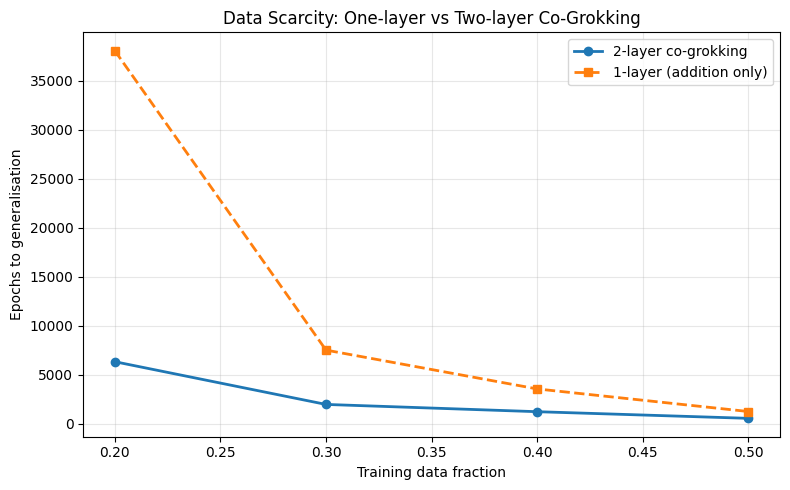


Summary:
  frac=20% → 2‑layer:  6328 epochs | 1‑layer: 38051 epochs
  frac=30% → 2‑layer:  1970 epochs | 1‑layer:  7512 epochs
  frac=40% → 2‑layer:  1229 epochs | 1‑layer:  3551 epochs
  frac=50% → 2‑layer:   551 epochs | 1‑layer:  1246 epochs


In [ ]:
# ============================================================
# Challenge 4 Extension: Co‑Grokking Data Scarcity (2‑layer)
# Fully self‑contained – copy into a new Colab notebook
# ============================================================
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import dataclasses
import shutil

# ---------- Configuration ----------
@dataclass(frozen=True)
class CONFIG:
    lr: float = 1e-3
    weight_decay: float = 0.3
    num_epochs: int = 30000
    batch_size: int = 512
    grad_clip: float = 1.0
    p: int = 113
    frac_train: float = 0.5    # will be overwritten per run
    seed: int = 0
    @property
    def OP_ADD(self): return self.p
    @property
    def OP_MULT(self): return self.p + 1
    @property
    def OP_EQ(self): return self.p + 2
    num_layers: int = 2
    d_model: int = 128
    num_heads: int = 4
    n_ctx: int = 4
    act_type: str = 'GeLU'
    use_ln: bool = True
    log_every: int = 500
    save_every: int = 1000
    @property
    def d_vocab(self): return self.p + 3
    @property
    def d_mlp(self): return 4 * self.d_model
    @property
    def d_head(self): return self.d_model // self.num_heads
    @property
    def device(self):
        return t.device('cuda' if t.cuda.is_available() else 'cpu')

# ---------- Helper functions ----------
def cross_entropy_high_precision(logits, labels):
    logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
    pred_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1)
    return -t.mean(pred_logprobs)

def compute_label(i, op, j, config):
    if op == config.OP_ADD:
        return (i + j) % config.p
    elif op == config.OP_MULT:
        return (i * j) % config.p
    raise ValueError

def gen_train_test(config):
    add_pairs = [(i, config.OP_ADD, j, config.OP_EQ) for i in range(config.p) for j in range(config.p)]
    mult_pairs = [(i, config.OP_MULT, j, config.OP_EQ) for i in range(config.p) for j in range(config.p)]
    random.seed(config.seed)
    random.shuffle(add_pairs)
    random.shuffle(mult_pairs)
    split = int(config.frac_train * len(add_pairs))
    train_data = add_pairs[:split] + mult_pairs[:split]
    test_data = add_pairs[split:] + mult_pairs[split:]
    random.shuffle(train_data)
    random.shuffle(test_data)
    return train_data, test_data

# ---------- Model classes (HookPoint, Embed, Unembed, PosEmbed, Attention, MLP, TransformerBlock, Transformer) ----------
# (Copy from your co‑grokking notebook – same as before, but I'll include a compact version)
class HookPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []
    def give_name(self, name): self.name = name
    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir == 'fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        else:
            raise NotImplementedError
    def remove_hooks(self, dir='fwd'):
        for h in self.fwd_hooks: h.remove()
        self.fwd_hooks = []
    def forward(self, x): return x

class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(t.randn(d_model, d_vocab)/np.sqrt(d_model))
    def forward(self, x):
        return t.einsum('dbp -> bpd', self.W_E[:, x])

class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(t.randn(d_model, d_vocab)/np.sqrt(d_vocab))
    def forward(self, x):
        return x @ self.W_U

class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(t.randn(max_ctx, d_model)/np.sqrt(d_model))
    def forward(self, x):
        return x + self.W_pos[:x.shape[-2]]

class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx):
        super().__init__()
        self.W_K = nn.Parameter(t.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_Q = nn.Parameter(t.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_V = nn.Parameter(t.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_O = nn.Parameter(t.randn(d_model, d_head*num_heads)/np.sqrt(d_model))
        self.register_buffer('mask', t.tril(t.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()
    def forward(self, x):
        k = self.hook_k(t.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(t.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(t.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = t.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = t.tril(attn_scores_pre) - 1e10*(1-self.mask[:x.shape[-2],:x.shape[-2]])
        attn_matrix = self.hook_attn(F.softmax(self.hook_attn_pre(attn_scores_masked/np.sqrt(self.d_head)), dim=-1))
        z = self.hook_z(t.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        return t.einsum('df,bqf->bqd', self.W_O, z_flat)

class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type):
        super().__init__()
        self.W_in = nn.Parameter(t.randn(d_mlp, d_model)/np.sqrt(d_model))
        self.b_in = nn.Parameter(t.zeros(d_mlp))
        self.W_out = nn.Parameter(t.randn(d_model, d_mlp)/np.sqrt(d_model))
        self.b_out = nn.Parameter(t.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
    def forward(self, x):
        x = self.hook_pre(t.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type == 'ReLU':
            x = F.relu(x)
        else:
            x = F.gelu(x)
        x = self.hook_post(x)
        return t.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out

class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_ln):
        super().__init__()
        self.use_ln = use_ln
        if use_ln:
            self.ln1 = nn.LayerNorm(d_model)
            self.ln2 = nn.LayerNorm(d_model)
        self.attn = Attention(d_model, num_heads, d_head, n_ctx)
        self.mlp = MLP(d_model, d_mlp, act_type)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()
    def forward(self, x):
        if self.use_ln:
            x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.ln1(self.hook_resid_pre(x)))))
            x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(self.ln2(x))))
        else:
            x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.hook_resid_pre(x))))
            x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(x)))
        return x

class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_ln=False):
        super().__init__()
        self.embed = Embed(d_vocab, d_model)
        self.pos_embed = PosEmbed(n_ctx, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, d_mlp, d_head, num_heads, n_ctx, act_type, use_ln) for _ in range(num_layers)])
        self.unembed = Unembed(d_vocab, d_model)
    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        return self.unembed(x)

# ---------- Trainer ----------
class Trainer:
    def __init__(self, config, save_root):
        self.config = config
        self.model = Transformer(
            num_layers=config.num_layers, d_vocab=config.d_vocab,
            d_model=config.d_model, d_mlp=config.d_mlp, d_head=config.d_head,
            num_heads=config.num_heads, n_ctx=config.n_ctx,
            act_type=config.act_type, use_ln=config.use_ln
        ).to(config.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=config.lr, weight_decay=config.weight_decay, betas=(0.9,0.98))
        self.scheduler = optim.lr_scheduler.LambdaLR(self.optimizer, lambda step: min(step/10,1))
        self.train_data, self.test_data = gen_train_test(config)
        self.train_losses = []
        self.test_losses = []
        self.train_loss_add = []
        self.train_loss_mult = []
        self.test_loss_add = []
        self.test_loss_mult = []
        self.saved_state_dicts = []
        self.saved_epochs = []
        print(f"Training samples: {len(self.train_data)}  Test samples: {len(self.test_data)}")

    def compute_losses(self, batch_data):
        data_tensor = t.tensor(batch_data).to(self.config.device)
        logits = self.model(data_tensor)[:, -1]
        labels = t.tensor([compute_label(i, op, j, self.config) for i, op, j, _ in batch_data]).to(self.config.device)
        ops = t.tensor([op for _, op, _, _ in batch_data]).to(self.config.device)
        mask_add = (ops == self.config.OP_ADD)
        mask_mult = (ops == self.config.OP_MULT)
        logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
        pred_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1).squeeze()
        total_loss = -t.mean(pred_logprobs)
        loss_add = -t.mean(pred_logprobs[mask_add]) if mask_add.any() else t.tensor(0.0)
        loss_mult = -t.mean(pred_logprobs[mask_mult]) if mask_mult.any() else t.tensor(0.0)
        return total_loss, loss_add, loss_mult

    def evaluate(self):
        self.model.eval()
        with t.no_grad():
            total_add, total_mult, n = 0.0, 0.0, 0
            for i in range(0, len(self.test_data), self.config.batch_size):
                batch = self.test_data[i:i+self.config.batch_size]
                _, loss_add, loss_mult = self.compute_losses(batch)
                total_add += loss_add.item()
                total_mult += loss_mult.item()
                n += 1
            mean_add = total_add / n
            mean_mult = total_mult / n
        self.model.train()
        return mean_add, mean_mult

    def step(self, epoch):
        indices = np.random.permutation(len(self.train_data))
        epoch_add, epoch_mult, n_batches = 0.0, 0.0, 0
        for start in range(0, len(self.train_data), self.config.batch_size):
            batch_idx = indices[start:start+self.config.batch_size]
            batch = [self.train_data[i] for i in batch_idx]
            loss, loss_add, loss_mult = self.compute_losses(batch)
            loss.backward()
            t.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
            self.optimizer.step()
            self.scheduler.step()
            self.optimizer.zero_grad()
            epoch_add += loss_add.item()
            epoch_mult += loss_mult.item()
            n_batches += 1
        mean_train_add = epoch_add / n_batches
        mean_train_mult = epoch_mult / n_batches
        test_add, test_mult = self.evaluate()
        self.train_loss_add.append(mean_train_add)
        self.train_loss_mult.append(mean_train_mult)
        self.test_loss_add.append(test_add)
        self.test_loss_mult.append(test_mult)
        if epoch % self.config.log_every == 0:
            print(f"Epoch {epoch:6d} | Train A:{mean_train_add:.4f} M:{mean_train_mult:.4f} | Test A:{test_add:.4f} M:{test_mult:.4f}")

    def save_checkpoint(self, epoch):
        sd = {k:v.cpu().clone() for k,v in self.model.state_dict().items()}
        self.saved_state_dicts.append(sd)
        self.saved_epochs.append(epoch)

def run_co_grokking_fraction(frac_train, max_epochs=30000, loss_threshold=0.1):
    cfg = CONFIG()
    # Make a mutable copy – but CONFIG is frozen, so we need to create a new instance with updated values.
    # Simpler: use dataclasses.replace.
    cfg = dataclasses.replace(cfg,
                              frac_train=frac_train,
                              num_epochs=max_epochs,
                              log_every=500,
                              save_every=1000)
    temp_root = Path(f"/tmp/co_grok_frac_{int(frac_train*100)}")
    temp_root.mkdir(exist_ok=True)
    trainer = Trainer(cfg, save_root=temp_root)
    grok_epoch = None
    start = time.time()
    for epoch in range(max_epochs):
        trainer.step(epoch)
        if (trainer.test_loss_add[-1] < loss_threshold and
            trainer.test_loss_mult[-1] < loss_threshold and
            grok_epoch is None):
            grok_epoch = epoch
            elapsed = time.time() - start
            print(f"  ✓ frac={frac_train:.0%} co‑grokked at epoch {epoch} ({elapsed/60:.1f} min)")
            break
        if epoch % 2000 == 0 and epoch > 0:
            print(f"    epoch {epoch}: add={trainer.test_loss_add[-1]:.3f}, mult={trainer.test_loss_mult[-1]:.3f}")
    if grok_epoch is None:
        grok_epoch = max_epochs
        print(f"  ✗ frac={frac_train:.0%} did not co‑grok within {max_epochs} epochs")
    shutil.rmtree(temp_root, ignore_errors=True)
    return grok_epoch

# ---------- Run experiment ----------
fractions = [0.2, 0.3, 0.4, 0.5]
co_grok_epochs = []
one_layer_epochs = [38051, 7512, 3551, 1246]   # from your earlier one‑layer run

print("="*60)
print("Co‑Grokking Data Scarcity Regime (2‑layer transformer)")
print("="*60)

for frac in fractions:
    print(f"\nRunning with frac_train = {frac:.0%} ...")
    epoch = run_co_grokking_fraction(frac, max_epochs=30000, loss_threshold=0.1)
    co_grok_epochs.append(epoch)

# Plot comparison
plt.figure(figsize=(8,5))
plt.plot(fractions, co_grok_epochs, marker='o', linestyle='-', linewidth=2, label='2‑layer co‑grokking')
plt.plot(fractions, one_layer_epochs, marker='s', linestyle='--', linewidth=2, label='1‑layer (addition only)')
plt.xlabel('Training data fraction')
plt.ylabel('Epochs to generalisation')
plt.title('Data Scarcity: One‑layer vs Two‑layer Co‑Grokking')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
for f, ce, oe in zip(fractions, co_grok_epochs, one_layer_epochs):
    print(f"  frac={f:.0%} → 2‑layer: {ce:5d} epochs | 1‑layer: {oe:5d} epochs")

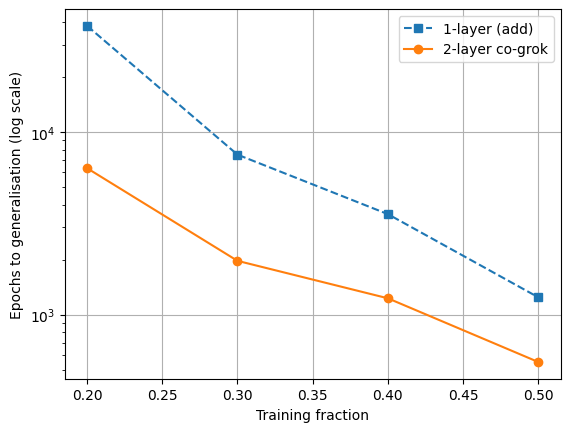

In [ ]:
plt.plot(fractions, [38051,7512,3551,1246], 's--', label='1‑layer (add)')
plt.plot(fractions, [6328,1970,1229,551], 'o-', label='2‑layer co‑grok')
plt.yscale('log')  # to see the difference clearly
plt.xlabel('Training fraction')
plt.ylabel('Epochs to generalisation (log scale)')
plt.legend()
plt.grid(True)
plt.show()